In [1]:
# in this project, I am going to try to load the grid and petrophysical properties and try to make a 2Dmap

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd


import plotly.express as px
import plotly.graph_objects as go


import re

### Porosity

In [3]:
def read_eclipse_keyword(file_path, keyword):

    text = Path(file_path).read_text(
        encoding="latin-1",
        errors="ignore"
    )

    # remove comments
    text = re.sub(r"--.*", "", text)

    # capture keyword block
    pattern = rf"\b{keyword}\b\s*(.*?)\s*/"

    match = re.search(
        pattern,
        text,
        flags=re.S | re.I
    )

    if match is None:
        raise ValueError(f"{keyword} not found")

    block = match.group(1)

    values = []

    for token in block.split():

        if "*" in token:
            n, val = token.split("*")
            values.extend([float(val)] * int(n))

        else:
            values.append(float(token))

    return np.array(values, dtype=float)

In [4]:
file_path = ("../../0_Volve_dataset/7_Reservoir_Model-Eclipse_model/Volve_sim_model_PPA-Eclipse Res Model/VOLVE_2016_EXPAND.DATA")
poro_values = read_eclipse_keyword(file_path, "PORO")

In [5]:
# check that the lenght of the poro list is the same size at the length of the grid 
len(poro_values)==108 * 100 * 63

True

In [6]:
poro_values.shape

(680400,)

In [7]:
NX, NY, NZ = 108, 100, 63

poro_3d = poro_values.reshape((NZ, NY, NX))
poro_avg = poro_3d.mean(axis=0)

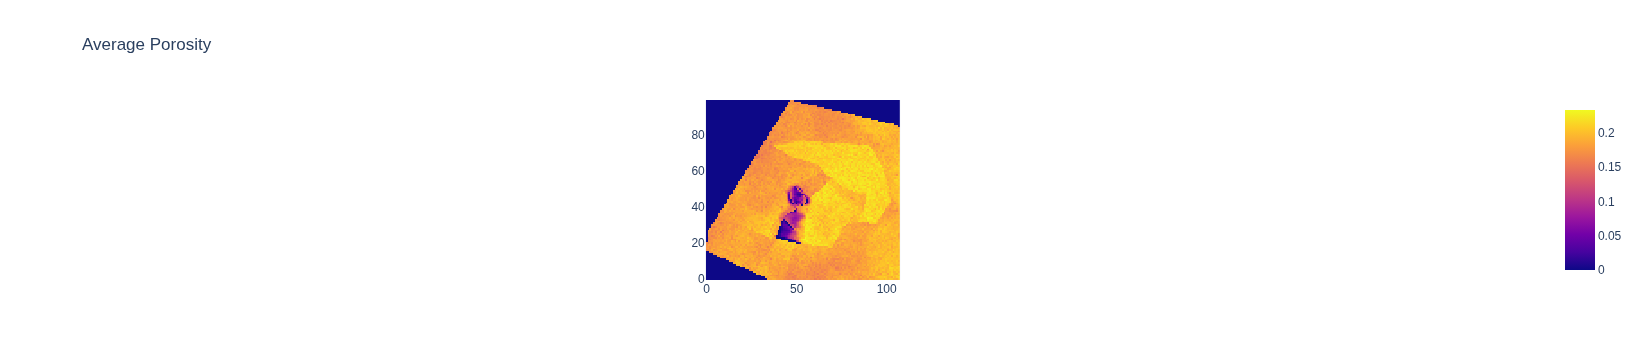

In [8]:

fig = px.imshow(
    poro_avg,
    origin="lower",
    title="Average Porosity"
)

fig.show()

#### Check that Eclipse well location matches NPD_WELL_BORE_NAME location

In [9]:
file_path = ("../../0_Volve_dataset/Processed_input/WELSPECS.xlsx")
WELSPECS_df = pd.read_excel(file_path)
WELSPECS_df

,Eclipse Wellname,Eclipse Groupname,I_index,J_index,Reference depth,Preferred phase,NPD_WELL_BORE_NAME
0,I-F-5,AAR,84,41,1.0,WAT,NaN
1,P-F-14,AAR,65,48,2476.1,LIQ,15/9-F-14
2,I-F-4,SRAR,73,28,1.0,WAT,15/9-F-4
3,I-F4G,SRAR,73,28,1.0,GAS,NaN
4,P-F-12,SRAR,58,37,2705.0,LIQ,15/9-F-12
5,P-F-15C,SRAR,55,28,2551.0,LIQ,NaN
6,P-F-11B,SRAR,66,42,2451.0,LIQ,15/9-F-11
7,P-F-N,P_NORTH,79,54,1.0,LIQ,NaN
8,I-F-N,P_NORTH,88,57,1.0,WAT,NaN
9,I-F-1ANW,P_NW,64,58,1.0,WAT,NaN


In [10]:
# change the I,J of the Poro grid to real x and y using MAPAXES
#MAPAXES
#432156.531 6476477.000
#432156.531 6481452.000
#437531.531 6481452.000

x_min = 432156.531
x_max = 437531.531

y_min = 6476477.000
y_max = 6481452.000

x_real = np.linspace(x_min, x_max, NX)
y_real = np.linspace(y_min, y_max, NY)

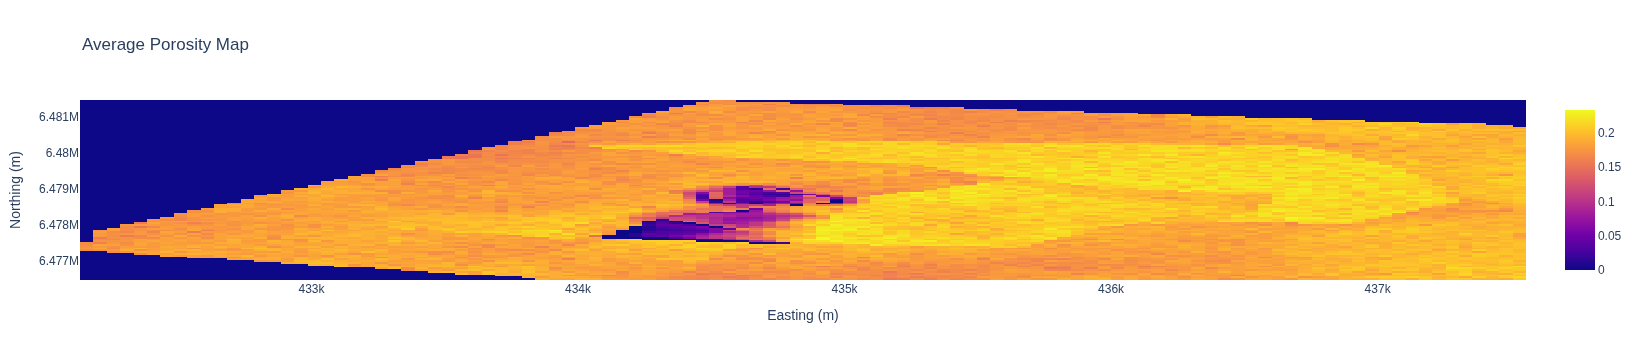

In [11]:
fig = px.imshow(
    poro_avg,
    x=x_real,
    y=y_real,
    origin="lower",
    aspect="auto",
    title="Average Porosity Map"
)

fig.update_layout(
    xaxis_title="Easting (m)",
    yaxis_title="Northing (m)"
)


In [12]:
# change the well I,J coordinates to real x y
dx = (x_max - x_min) / (NX - 1)
dy = (y_max - y_min) / (NY - 1)
WELSPECS_df["Easting_m"] = (x_min+ (WELSPECS_df["I_index"] - 1) * dx)
WELSPECS_df["Northing_m"] = (y_min+ (WELSPECS_df["J_index"] - 1) * dy)
WELSPECS_df

,Eclipse Wellname,Eclipse Groupname,I_index,J_index,Reference depth,Preferred phase,NPD_WELL_BORE_NAME,Easting_m,Northing_m
0,I-F-5,AAR,84,41,1.0,WAT,NaN,436325.923523,6.478487e+06
1,P-F-14,AAR,65,48,2476.1,LIQ,15/9-F-14,435371.484271,6.478839e+06
2,I-F-4,SRAR,73,28,1.0,WAT,15/9-F-4,435773.353430,6.477834e+06
3,I-F4G,SRAR,73,28,1.0,GAS,NaN,435773.353430,6.477834e+06
4,P-F-12,SRAR,58,37,2705.0,LIQ,15/9-F-12,435019.848757,6.478286e+06
5,P-F-15C,SRAR,55,28,2551.0,LIQ,NaN,434869.147822,6.477834e+06
6,P-F-11B,SRAR,66,42,2451.0,LIQ,15/9-F-11,435421.717916,6.478537e+06
7,P-F-N,P_NORTH,79,54,1.0,LIQ,NaN,436074.755299,6.479140e+06
8,I-F-N,P_NORTH,88,57,1.0,WAT,NaN,436526.858103,6.479291e+06
9,I-F-1ANW,P_NW,64,58,1.0,WAT,NaN,435321.250626,6.479341e+06


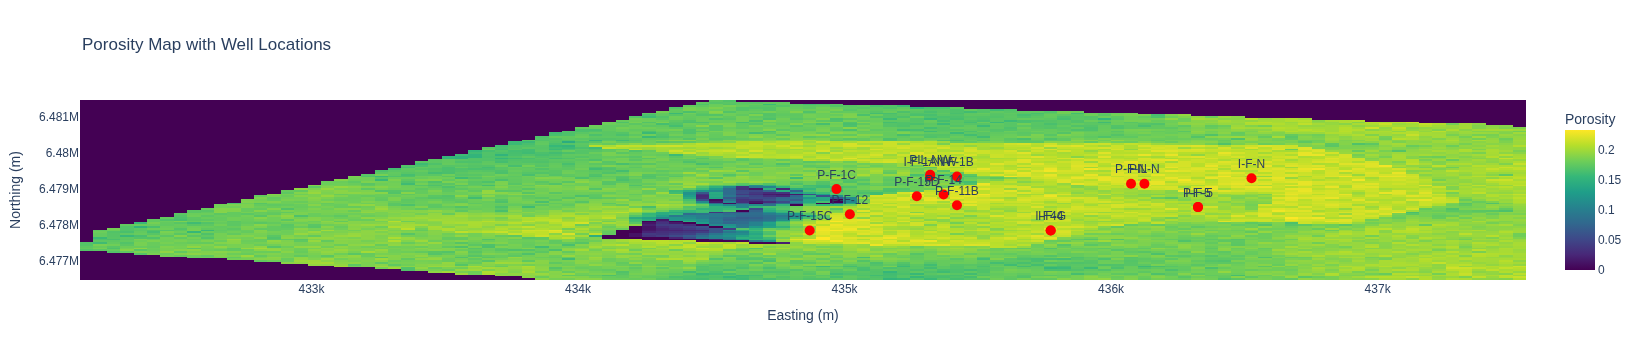

In [13]:
# plot the Eclipse Wellname location from the WELSPECS_df on the porosity map
fig = go.Figure()

# porosity map
fig.add_trace(
             go.Heatmap(x=x_real,y=y_real,z=poro_avg,colorscale="Viridis",colorbar={"title": "Porosity"})
              )

# wells
fig.add_trace(
            go.Scatter(x=WELSPECS_df["Easting_m"],y=WELSPECS_df["Northing_m"],mode="markers+text",text=WELSPECS_df["Eclipse Wellname"],textposition="top center",
                       marker={"size": 10, "color": "red"},name="Wells")
             )

fig.update_layout(title="Porosity Map with Well Locations",xaxis_title="Easting (m)",yaxis_title="Northing (m)")

fig.show()

In [14]:
# check whether the welllocation from the production dataframe is the same 
# load the production data 
import sys
sys.path.append("../src")   # VERY IMPORTANT
from Load_clean_production_data import Load_clean_production_data
file_path = ("../../0_Volve_dataset/5_Production_data/Volve_production_data.xlsx")
production_df = Load_clean_production_data(file_path)
from Load_clean_production_data import metric_to_field
production_df_field=pd.DataFrame()
production_df_field=metric_to_field(production_df)
production_df_field

,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE_PSI,...,AVG_CHOKE_UOM,AVG_WHP_P_PSI,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL_STB,BORE_GAS_VOL_MSCF,BORE_WAT_VOL_STB,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
0,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.000000,...,%,0.000000,32.000000,0.00000,0.0,0.0,0.0,NaN,production,WI
1,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.000000,32.000000,0.00000,0.0,0.0,0.0,NaN,production,OP
2,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.000000,32.000000,0.00000,0.0,0.0,0.0,NaN,production,OP
3,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.000000,32.000000,0.00000,0.0,0.0,0.0,NaN,production,OP
4,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,4501.633459,...,%,480.045032,50.863856,33.07195,0.0,0.0,0.0,NaN,production,OP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15629,2016-09-14,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,1.127815,32.411822,0.01862,0.0,0.0,0.0,NaN,production,OP
15630,2016-09-15,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,1.239350,32.412452,0.00631,0.0,0.0,0.0,NaN,production,OP
15631,2016-09-16,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,1.239205,32.412128,0.01181,0.0,0.0,0.0,NaN,production,OP
15632,2016-09-17,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,1.087350,32.411228,0.02576,0.0,0.0,0.0,NaN,production,OP


In [15]:
# drop columns u dont need
production_df_field = production_df_field.drop(columns=[
    col for col in [
        "WELL_BORE_CODE",
        "NPD_WELL_BORE_CODE",
       "NPD_FIELD_CODE",
       "ON_STREAM_HRS",
        "NPD_FIELD_NAME",
        "NPD_FACILITY_CODE",
        "NPD_FACILITY_NAME",
        "NPD_FIELD_CODE",
        'BORE_WI_VOL', 
        'FLOW_KIND',
        'WELL_TYPE'
        ] if col in production_df_field.columns
    ])

production_df_field

,DATEPRD,NPD_WELL_BORE_NAME,AVG_DOWNHOLE_PRESSURE_PSI,AVG_DOWNHOLE_TEMPERATURE_F,AVG_DP_TUBING_PSI,AVG_ANNULUS_PRESS_PSI,AVG_CHOKE_SIZE_P,AVG_CHOKE_UOM,AVG_WHP_P_PSI,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL_STB,BORE_GAS_VOL_MSCF,BORE_WAT_VOL_STB
0,2014-04-07,15/9-F-1 C,0.000000,32.000000,0.000000,0.000000,0.000000,%,0.000000,32.000000,0.00000,0.0,0.0,0.0
1,2014-04-08,15/9-F-1 C,NaN,NaN,NaN,0.000000,1.003059,%,0.000000,32.000000,0.00000,0.0,0.0,0.0
2,2014-04-09,15/9-F-1 C,NaN,NaN,NaN,0.000000,0.979008,%,0.000000,32.000000,0.00000,0.0,0.0,0.0
3,2014-04-10,15/9-F-1 C,NaN,NaN,NaN,0.000000,0.545759,%,0.000000,32.000000,0.00000,0.0,0.0,0.0
4,2014-04-11,15/9-F-1 C,4501.633459,206.376602,4021.588427,0.000000,1.215987,%,480.045032,50.863856,33.07195,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15629,2016-09-14,15/9-F-5,NaN,NaN,NaN,3.955476,0.636088,%,1.127815,32.411822,0.01862,0.0,0.0,0.0
15630,2016-09-15,15/9-F-5,NaN,NaN,NaN,4.160560,0.670794,%,1.239350,32.412452,0.00631,0.0,0.0,0.0
15631,2016-09-16,15/9-F-5,NaN,NaN,NaN,4.148667,0.664393,%,1.239205,32.412128,0.01181,0.0,0.0,0.0
15632,2016-09-17,15/9-F-5,NaN,NaN,NaN,3.946774,0.624660,%,1.087350,32.411228,0.02576,0.0,0.0,0.0


In [16]:
# manually add the coordinates from the xy table to the production data
production_df_field["lat_dd"]=None
production_df_field["lon_dd"]=None

production_df_field.loc[production_df['NPD_WELL_BORE_NAME'] == '15/9-F-1 C', 'lat_dd'] = 58.429546
production_df_field.loc[production_df_field['NPD_WELL_BORE_NAME'] == '15/9-F-1 C', 'lon_dd'] = 1.887518

production_df_field.loc[production_df_field['NPD_WELL_BORE_NAME'] == '15/9-F-11', 'lat_dd'] = 58.441655
production_df_field.loc[production_df_field['NPD_WELL_BORE_NAME'] == '15/9-F-11', 'lon_dd'] = 1.887463

production_df_field.loc[production_df_field['NPD_WELL_BORE_NAME'] == '15/9-F-12', 'lat_dd'] = 58.440708	
production_df_field.loc[production_df_field['NPD_WELL_BORE_NAME'] == '15/9-F-12', 'lon_dd'] = 1.878978

production_df_field.loc[production_df_field['NPD_WELL_BORE_NAME'] == '15/9-F-14', 'lat_dd'] = 58.441602	
production_df_field.loc[production_df_field['NPD_WELL_BORE_NAME'] == '15/9-F-14', 'lon_dd'] = 1.887522

production_df_field.loc[production_df_field['NPD_WELL_BORE_NAME'] == '15/9-F-15 D', 'lat_dd'] = 58.441585	
production_df_field.loc[production_df_field['NPD_WELL_BORE_NAME'] == '15/9-F-15 D', 'lon_dd'] = 1.887541

production_df_field.loc[production_df_field['NPD_WELL_BORE_NAME'] == '15/9-F-4', 'lat_dd'] = 58.441589	
production_df_field.loc[production_df_field['NPD_WELL_BORE_NAME'] == '15/9-F-4', 'lon_dd'] = 1.887478

production_df_field.loc[production_df_field['NPD_WELL_BORE_NAME'] == '15/9-F-5', 'lat_dd'] = 58.441571	
production_df_field.loc[production_df_field['NPD_WELL_BORE_NAME'] == '15/9-F-5', 'lon_dd'] = 1.887497

In [17]:
# change the lat lon to xy
from pyproj import Transformer

transformer = Transformer.from_crs(
    "EPSG:4326",   # WGS84 lat/lon
    "EPSG:32631",  # UTM zone 31N
    always_xy=True
)
production_df_field["Easting_m"], production_df_field["Northing_m"] = transformer.transform(production_df_field["lon_dd"].values,production_df_field["lat_dd"].values)

In [18]:
production_df_field

,DATEPRD,NPD_WELL_BORE_NAME,AVG_DOWNHOLE_PRESSURE_PSI,AVG_DOWNHOLE_TEMPERATURE_F,AVG_DP_TUBING_PSI,AVG_ANNULUS_PRESS_PSI,AVG_CHOKE_SIZE_P,AVG_CHOKE_UOM,AVG_WHP_P_PSI,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL_STB,BORE_GAS_VOL_MSCF,BORE_WAT_VOL_STB,lat_dd,lon_dd,Easting_m,Northing_m
0,2014-04-07,15/9-F-1 C,0.000000,32.000000,0.000000,0.000000,0.000000,%,0.000000,32.000000,0.00000,0.0,0.0,0.0,58.429546,1.887518,435033.228732,6.477072e+06
1,2014-04-08,15/9-F-1 C,NaN,NaN,NaN,0.000000,1.003059,%,0.000000,32.000000,0.00000,0.0,0.0,0.0,58.429546,1.887518,435033.228732,6.477072e+06
2,2014-04-09,15/9-F-1 C,NaN,NaN,NaN,0.000000,0.979008,%,0.000000,32.000000,0.00000,0.0,0.0,0.0,58.429546,1.887518,435033.228732,6.477072e+06
3,2014-04-10,15/9-F-1 C,NaN,NaN,NaN,0.000000,0.545759,%,0.000000,32.000000,0.00000,0.0,0.0,0.0,58.429546,1.887518,435033.228732,6.477072e+06
4,2014-04-11,15/9-F-1 C,4501.633459,206.376602,4021.588427,0.000000,1.215987,%,480.045032,50.863856,33.07195,0.0,0.0,0.0,58.429546,1.887518,435033.228732,6.477072e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15629,2016-09-14,15/9-F-5,NaN,NaN,NaN,3.955476,0.636088,%,1.127815,32.411822,0.01862,0.0,0.0,0.0,58.441571,1.887497,435054.153861,6.478411e+06
15630,2016-09-15,15/9-F-5,NaN,NaN,NaN,4.160560,0.670794,%,1.239350,32.412452,0.00631,0.0,0.0,0.0,58.441571,1.887497,435054.153861,6.478411e+06
15631,2016-09-16,15/9-F-5,NaN,NaN,NaN,4.148667,0.664393,%,1.239205,32.412128,0.01181,0.0,0.0,0.0,58.441571,1.887497,435054.153861,6.478411e+06
15632,2016-09-17,15/9-F-5,NaN,NaN,NaN,3.946774,0.624660,%,1.087350,32.411228,0.02576,0.0,0.0,0.0,58.441571,1.887497,435054.153861,6.478411e+06


In [19]:
# fetch the polygon and make it into a dataframe
from Find_Load_plot_X_Y_loc import poly
file_path = Path("../../0_Volve_dataset/2_Geophysical_Interpretations/Fault_polygons/2014_Volve_Hugin_Base.dat")
df_poly=poly(file_path)
df_poly

,polygon_id,point_order,x,y,z
0,71,1,435259.53,6479503.5,2714.235352
1,71,2,435219.94,6479501.0,2706.789307
2,71,3,435181.06,6479502.0,2710.512207
3,71,4,435163.38,6479498.5,2712.498047
4,71,5,435115.31,6479473.0,2708.030273
...,...,...,...,...,...
1495,0,8,436859.97,6479294.0,2804.401123
1496,0,9,436772.91,6479190.0,2807.272949
1497,0,10,436700.34,6479132.0,2805.930420
1498,0,11,436668.19,6479116.5,2756.585205


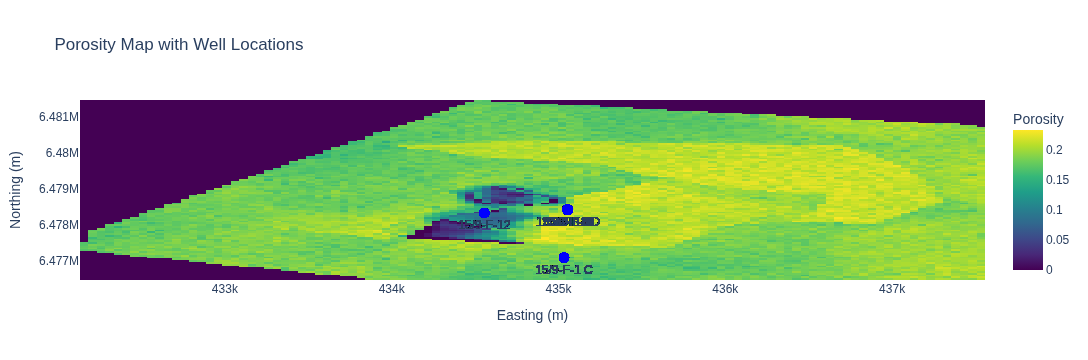

In [76]:
# plot the Eclipse Wellname location from the WELSPECS_df on the porosity map
fig = go.Figure()

# porosity map
fig.add_trace(
             go.Heatmap(x=x_real,y=y_real,z=poro_avg,colorscale="Viridis",colorbar={"title": "Porosity"})
              )

# wells coordinate from WELSPECS_df
#fig.add_trace(
            #go.Scatter(x=WELSPECS_df["Easting"],y=WELSPECS_df["Northing"],mode="markers+text",text=WELSPECS_df["Eclipse Wellname"],textposition="top center",
                       #marker={"size": 10, "color": "red"},name="Wells")
             #)

# wells coordinate from production_df_field
fig.add_trace(
            go.Scatter(x=production_df_field["Easting_m"],y=production_df_field["Northing_m"],
                       mode="markers+text",
                       text=production_df_field["NPD_WELL_BORE_NAME"],
                       textposition="bottom center",
                       marker={"size": 10, "color": "blue"},
                       hoveron ="points",
                       name="Wells from prod DF")
             )

fig.update_layout(title="Porosity Map with Well Locations",xaxis_title="Easting (m)",yaxis_title="Northing (m)")

fig.show()

In [77]:
production_df['NPD_WELL_BORE_NAME'].unique()

<StringArray>
[ '15/9-F-1 C',   '15/9-F-11',   '15/9-F-12',   '15/9-F-14', '15/9-F-15 D',
    '15/9-F-4',    '15/9-F-5']
Length: 7, dtype: str